Github repo- https://github.com/saurabhsen848/Generative-AI_Assignment.git


Step 1: Setup and imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score

np.random.seed(42)

Step 2: Load MNIST and filter to digits 0 and 1

In [ ]:
print("Fetching MNIST (may take a minute)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

# Keep only 0s and 1s
mask = (y == 0) | (y == 1)
X_01 = X[mask]
y_01 = y[mask]

# Normalize pixel values to [0,1]
X_01 = X_01 / 255.0

print("Shape:", X_01.shape, "Labels:", np.unique(y_01))

Fetching MNIST (may take a minute)...
Shape: (14780, 784) Labels: [0 1]


Step 3: Train/test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_01, y_01, test_size=0.2, random_state=42, stratify=y_01
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (11824, 784) Test: (2956, 784)


Step 4: Visualize a few sample digits

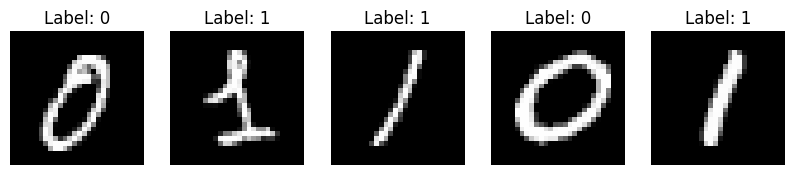

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.show()

Step 5: Discriminative model — Logistic Regression

In [ ]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Discriminative model accuracy: {acc:.4f}")

Discriminative model accuracy: 0.9983


Step 6: Visualize predictions

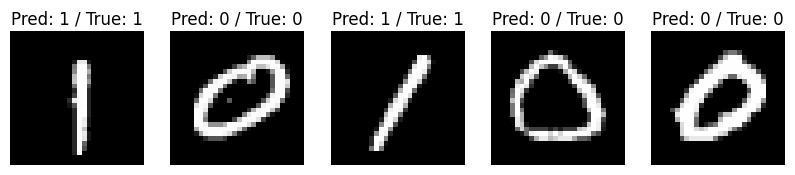

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred: {y_pred[i]} / True: {y_test[i]}")
    ax.axis('off')
plt.show()

Step 7: Generative model — Gaussian Mixture Model

We train one GMM per class so each learns the distribution of pixels for that digit.

In [ ]:
# Separate data by class
X_train_0 = X_train[y_train == 0]
X_train_1 = X_train[y_train == 1]

gmm_0 = GaussianMixture(n_components=5, covariance_type='diag', random_state=42)
gmm_0.fit(X_train_0)

gmm_1 = GaussianMixture(n_components=5, covariance_type='diag', random_state=42)
gmm_1.fit(X_train_1)

print("GMMs trained.")

GMMs trained.


Step 8: Generate new digit images

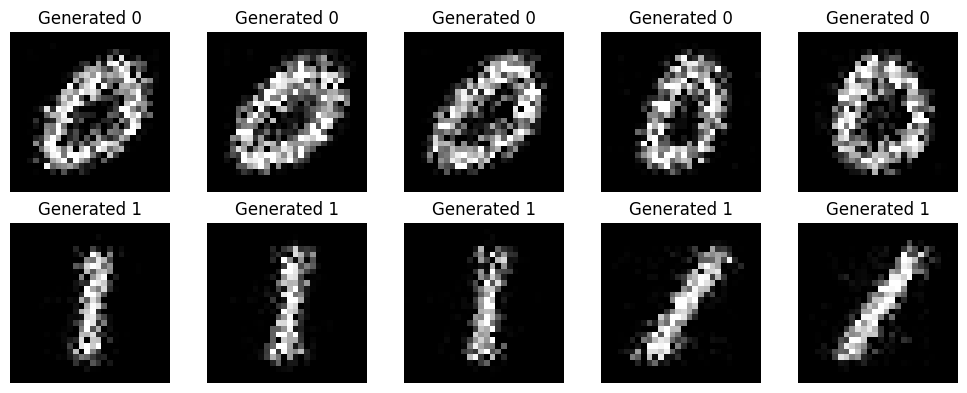

In [ ]:
# Sample new synthetic digits
generated_0, _ = gmm_0.sample(5)
generated_1, _ = gmm_1.sample(5)

# Clip values to valid pixel range
generated_0 = np.clip(generated_0, 0, 1)
generated_1 = np.clip(generated_1, 0, 1)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axes[0, i].imshow(generated_0[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title("Generated 0")
    axes[0, i].axis('off')
    axes[1, i].imshow(generated_1[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title("Generated 1")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

Step 9: Visual comparison — real vs. predicted vs. generated

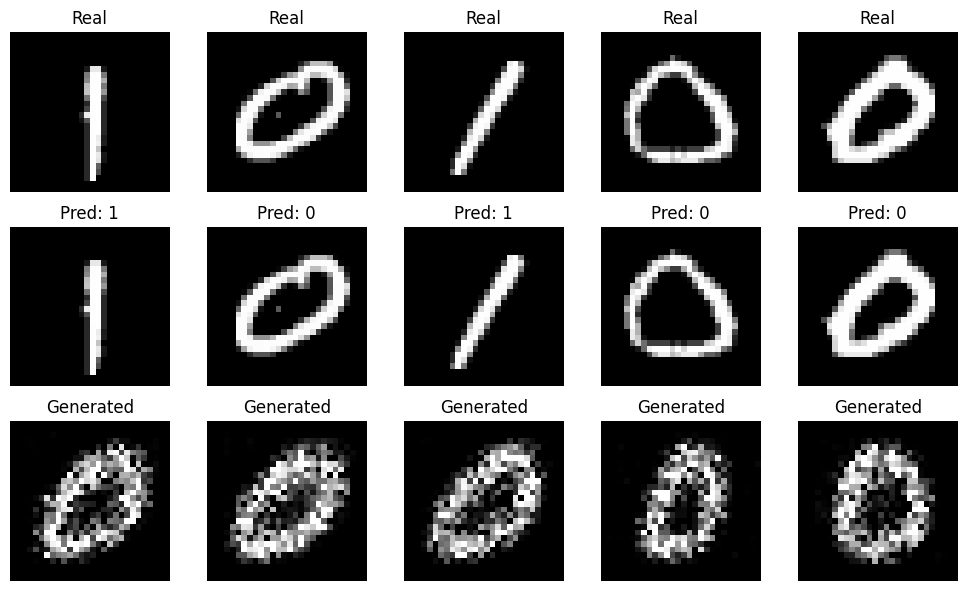

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for i in range(5):
    axes[0, i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title("Real")
    axes[0, i].axis('off')

    axes[1, i].imshow(X_test[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f"Pred: {y_pred[i]}")
    axes[1, i].axis('off')

    gen_img = generated_0[i] if i < len(generated_0) else generated_1[i - len(generated_0)]
    axes[2, i].imshow(gen_img.reshape(28, 28), cmap='gray')
    axes[2, i].set_title("Generated")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()